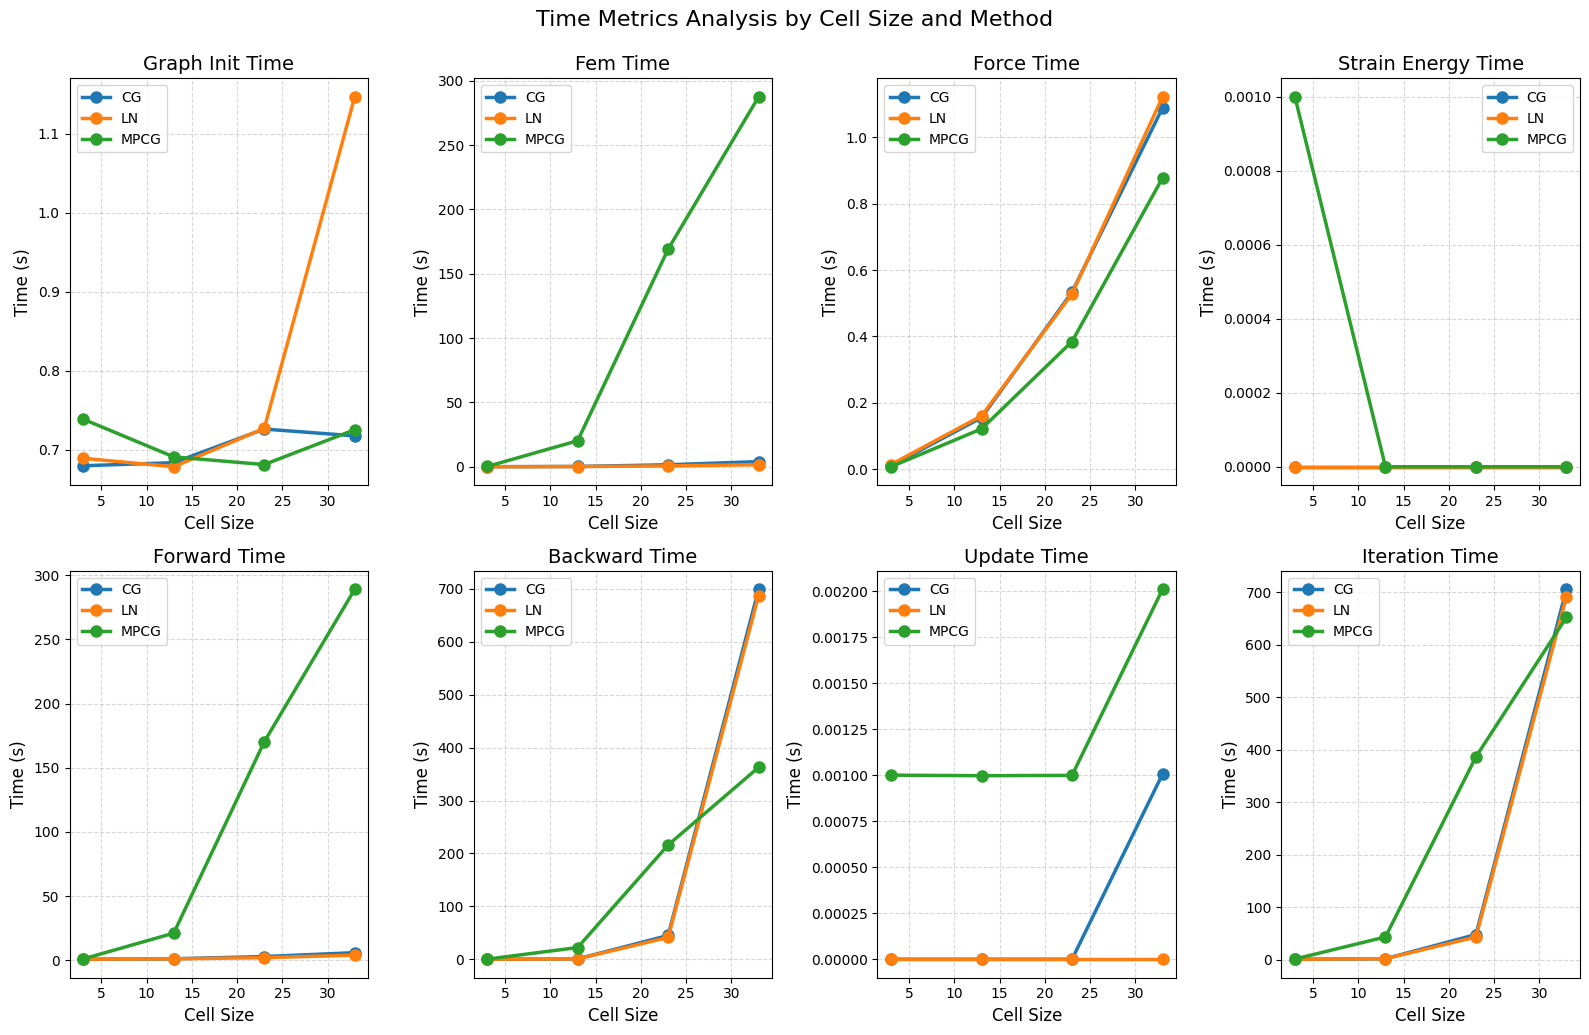

In [1]:
import json
import matplotlib.pyplot as plt

# 配置参数
categories = ['cg', 'ln', 'mpcg']
cell_sizes = [3, 13, 23, 33]
colors = {'cg': '#1f77b4', 'ln': '#ff7f0e', 'mpcg': '#2ca02c'}  # 保留颜色区分
metrics = [
    'graph_init_time', 'fem_time', 'force_time', 'strain_energy_time',
    'forward_time', 'backward_time', 'update_time', 'iteration_time'
]

# 加载数据
data = {cat: {metric: [] for metric in metrics} for cat in categories}

for size in cell_sizes:
    for cat in categories:
        filename = f"{cat}_{size}.json"
        try:
            with open(filename) as f:
                file_data = json.load(f)
                iteration_data = file_data['iteration_0']
                for metric in metrics:
                    data[cat][metric].append(iteration_data[metric])
        except Exception as e:
            print(f"加载 {filename} 出错: {str(e)}")
            for metric in metrics:
                data[cat][metric].append(0)

# 绘制图表（统一使用实线）
plt.figure(figsize=(16, 10))
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 4, i)
    for cat in categories:
        plt.plot(
            cell_sizes, data[cat][metric],
            linestyle='-',  # 统一实线
            color=colors[cat],
            marker='o',
            markersize=8,
            linewidth=2.5,
            label=f'{cat.upper()}'
        )
    plt.xlabel("Cell Size", fontsize=12)
    plt.ylabel("Time (s)", fontsize=12)
    plt.title(metric.replace('_', ' ').title(), fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(fontsize=10)

plt.tight_layout()
plt.suptitle("Time Metrics Analysis by Cell Size and Method", fontsize=16, y=1.03)
plt.show()

In [5]:
import json

with open('cg_3.json') as f:
    data = json.load(f)
    print("cg_3.json的实际结构：")
    print(json.dumps(data, indent=2))

cg_3.json的实际结构：
{
  "iteration_0": {
    "graph_init_time": 0.679854154586792,
    "fem_time": 0.03310656547546387,
    "force_time": 0.010228395462036133,
    "strain_energy_time": 0.0,
    "forward_time": 0.723189115524292,
    "backward_time": 0.02211451530456543,
    "update_time": 0.0,
    "iteration_time": 0.7453036308288574
  }
}


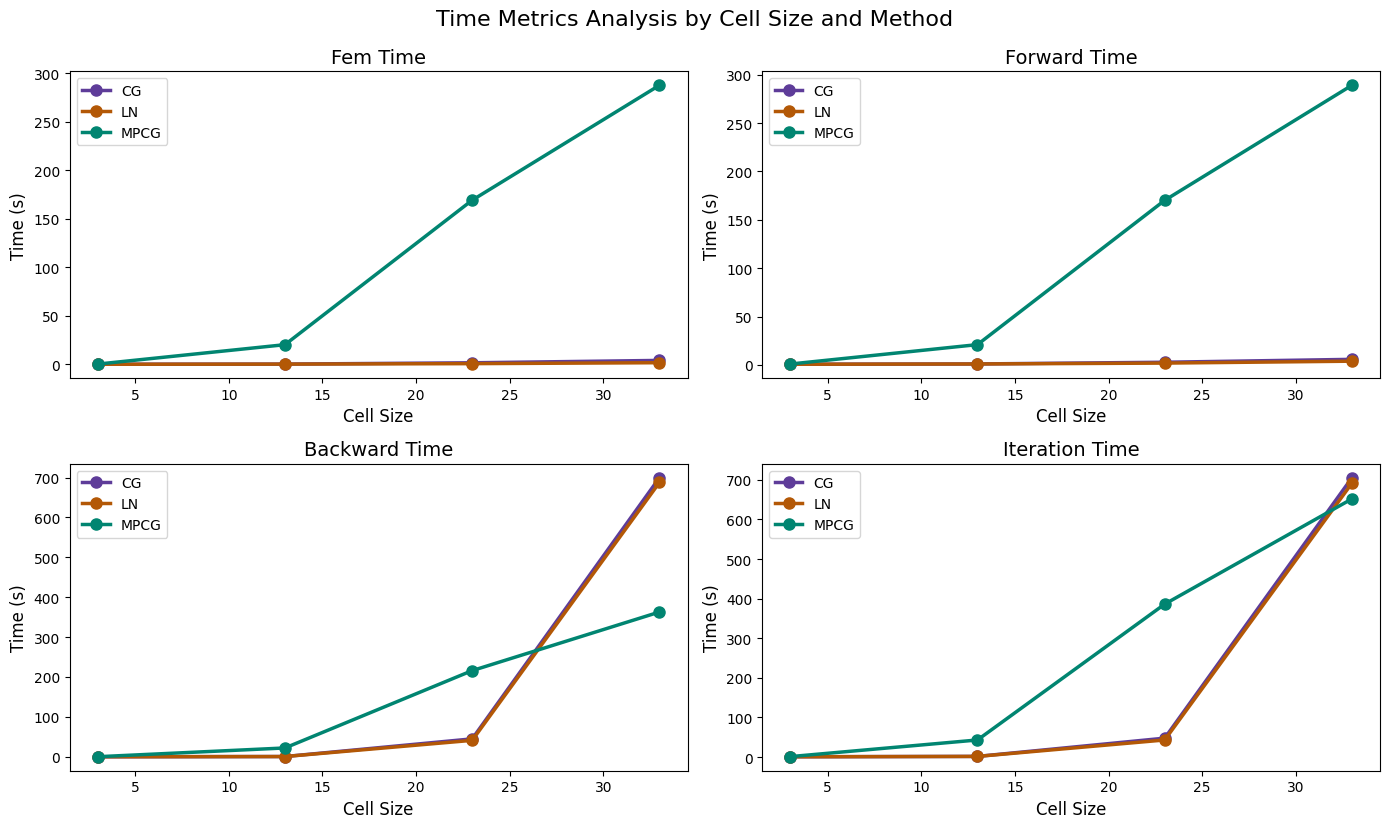

In [2]:
import json
import matplotlib.pyplot as plt

# 配置参数
categories = ['cg', 'ln', 'mpcg']
cell_sizes = [3, 13, 23, 33]
# 使用非常规的三种颜色：深紫色、深橙色、深青色
colors = {'cg': '#5e3c99', 'ln': '#b35806', 'mpcg': '#018571'}  
selected_metrics = ['fem_time', 'forward_time', 'backward_time', 'iteration_time']

# 加载数据
data = {cat: {metric: [] for metric in selected_metrics} for cat in categories}

for size in cell_sizes:
    for cat in categories:
        filename = f"{cat}_{size}.json"
        try:
            with open(filename) as f:
                file_data = json.load(f)
                iteration_data = file_data['iteration_0']
                for metric in selected_metrics:
                    data[cat][metric].append(iteration_data[metric])
        except Exception as e:
            print(f"加载 {filename} 出错: {str(e)}")
            for metric in selected_metrics:
                data[cat][metric].append(0)

# 绘制图表
plt.figure(figsize=(14, 8))
for i, metric in enumerate(selected_metrics, 1):
    plt.subplot(2, 2, i)
    for cat in categories:
        plt.plot(
            cell_sizes, data[cat][metric],
            linestyle='-',
            color=colors[cat],
            marker='o',
            markersize=8,
            linewidth=2.5,
            label=f'{cat.upper()}'
        )
    plt.xlabel("Cell Size", fontsize=12)
    plt.ylabel("Time (s)", fontsize=12)
    plt.title(metric.replace('_', ' ').title(), fontsize=14)
    # 移除网格线
    plt.grid(False)
    plt.legend(fontsize=10)

plt.tight_layout()
plt.suptitle("Time Metrics Analysis by Cell Size and Method", fontsize=16, y=1.03)
plt.show()